In [1]:
import matplotlib.pyplot as plt
## Importing required libraries
import numpy as np
%matplotlib inline
#%matplotlib notebook
import seaborn as sns
import pandas as pd

data = pd.HDFStore('bdv-data.h5')
print(data.keys())
df = data.get('gifi8_four_classification')
data.close()
print(df.columns)
df.describe()


['/all_nine_years', '/flat', '/gifi', '/gifi8_four_classification']
Index(['total_assets_less_cur._liab._th_gbp', 'net_assets_th_gbp',
       'net_tangible_assets_(liab.)_th_gbp', 'total_assets_th_gbp',
       'net_current_assets_(working_capital)_th_gbp',
       'shareholders_funds_th_gbp', 'current_assets_th_gbp',
       'total_reserves_th_gbp', 'current_liabilities_th_gbp',
       'solvency_ratio_(asset_based)_(%)',
       ...
       'other_income_pre_gp_th_gbp', 'other_auditors_services_th_gbp',
       'costs_of_reorganisation_th_gbp',
       'non-audit_fees_paid_to_other_auditors_th_gbp',
       'exceptional_items_pre_gp_th_gbp',
       'profit_(loss)_on_sale_of_operations_th_gbp',
       'UP_solvency_ratio_(asset_based)_(%)',
       'UP_solvency_ratio_(liability_based)_(%)', 'UP_liquidity_ratio_(x)',
       'UP_shareholders_liquidity_ratio_(x)'],
      dtype='object', length=181)


,total_assets_less_cur._liab._th_gbp,net_assets_th_gbp,net_tangible_assets_(liab.)_th_gbp,total_assets_th_gbp,net_current_assets_(working_capital)_th_gbp,shareholders_funds_th_gbp,current_assets_th_gbp,total_reserves_th_gbp,current_liabilities_th_gbp,solvency_ratio_(asset_based)_(%),...,impairment_th_gbp,dividends_th_gbp,preference_shares_th_gbp,management_of_liquid_resources_th_gbp,other_income_pre_gp_th_gbp,other_auditors_services_th_gbp,costs_of_reorganisation_th_gbp,non-audit_fees_paid_to_other_auditors_th_gbp,exceptional_items_pre_gp_th_gbp,profit_(loss)_on_sale_of_operations_th_gbp
count,56442.000000,56161.000000,56106.000000,55980.000000,55986.000000,54731.000000,54960.000000,50811.000000,49774.000000,47931.000000,...,19.000000,37.000000,20.000000,2.000000,5.000000,5.000000,2.000000,0.0,0.0,0.0
mean,558.717057,85.179687,530.176777,896.492099,80.163124,89.669608,421.006773,63.792445,-374.704054,29.262737,...,1603.124579,-32.627986,-450.392150,-3455.849500,-30.729000,0.882000,32.611500,NaN,NaN,NaN
std,8121.401469,3911.157239,8096.779810,10410.697657,4437.379553,3931.316432,6574.993936,4057.215475,5571.589373,43.863004,...,3604.592515,75.407203,726.470898,5012.185704,70.602452,1.316195,62.067712,NaN,NaN,NaN
min,-50989.550000,-114579.079352,-119059.000000,0.000903,-162089.000000,-59063.000000,0.000903,-59063.000000,-503436.373000,-100.000000,...,1.000000,-360.000000,-1666.666000,-7000.000000,-157.000000,0.100000,-11.277000,NaN,NaN,NaN
25%,0.007000,-0.368000,0.002000,5.507750,-3.149000,-0.523000,3.694000,-1.440000,-53.840000,0.839803,...,37.500000,-22.000000,-708.604000,-5227.924750,0.001000,0.150000,10.667250,NaN,NaN,NaN
50%,2.894000,0.858000,2.546000,21.221000,0.450000,1.000000,15.467500,1.287000,-17.059500,20.690358,...,237.398000,-8.000000,-13.184500,-3455.849500,0.003000,0.350000,32.611500,NaN,NaN,NaN
75%,22.407750,10.597000,20.814500,78.128500,9.958000,11.190000,53.166500,12.246500,-5.305500,63.557079,...,1186.781500,-2.845464,-0.265000,-1683.774250,0.007000,0.600000,54.555750,NaN,NaN,NaN
max,443312.769687,421712.000000,443312.769687,518202.338568,392010.000000,421712.000000,511953.588000,421712.000000,-0.001000,100.000000,...,15398.539000,-0.001000,-0.010000,88.301000,3.344000,3.210000,76.500000,NaN,NaN,NaN


In [2]:
yZ = ['UP_solvency_ratio_(asset_based)_(%)',
       'UP_solvency_ratio_(liability_based)_(%)', 'UP_liquidity_ratio_(x)',
       'UP_shareholders_liquidity_ratio_(x)']

y = 'UP_solvency_ratio_(asset_based)_(%)'

populated = ['total_assets_less_cur._liab._th_gbp', 'net_assets_th_gbp',
       'net_tangible_assets_(liab.)_th_gbp', 'total_assets_th_gbp',
       'net_current_assets_(working_capital)_th_gbp',
       'shareholders_funds_th_gbp', 'current_assets_th_gbp',
       'total_reserves_th_gbp', 'current_liabilities_th_gbp']

populated + [y]

df_mp = df[populated + [y]]
print(df_mp.shape)
_df = df_mp.dropna()
print(_df.shape)
_df.reset_index(drop=True, inplace=True)
print(_df.columns)

(56584, 10)
(45700, 10)
Index(['total_assets_less_cur._liab._th_gbp', 'net_assets_th_gbp',
       'net_tangible_assets_(liab.)_th_gbp', 'total_assets_th_gbp',
       'net_current_assets_(working_capital)_th_gbp',
       'shareholders_funds_th_gbp', 'current_assets_th_gbp',
       'total_reserves_th_gbp', 'current_liabilities_th_gbp',
       'UP_solvency_ratio_(asset_based)_(%)'],
      dtype='object')


In [9]:
x_unscaled = _df.sample(frac=1, replace=True, random_state=1)
y = x_unscaled['UP_solvency_ratio_(asset_based)_(%)']
x_unscaled.drop(['UP_solvency_ratio_(asset_based)_(%)'],axis=1, inplace=True)
x_unscaled[['total_assets_less_cur._liab._th_gbp', 'net_assets_th_gbp']].describe()

,total_assets_less_cur._liab._th_gbp,net_assets_th_gbp
count,45700.000000,45700.000000
mean,626.110888,121.474239
std,8846.674092,5117.580513
min,-50989.550000,-114579.079352
25%,0.105000,-1.033250
50%,4.212500,1.747000
75%,26.122250,14.839250
max,438365.000000,421712.000000


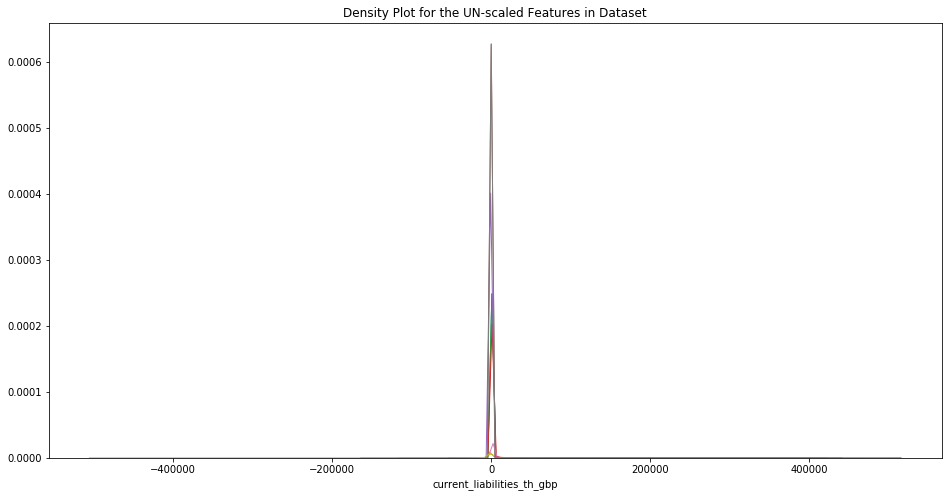

In [6]:
plt.figure(figsize=(16,8))
plt.title('Density Plot for the UN-scaled Features in Dataset')
for i in x_unscaled.columns:
    # Draw the density plot
    sns.distplot(x_unscaled[i], hist = False, kde = True,
                 kde_kws = {'linewidth': 1})
    

## Scale the features
The SMV performs faster if features are scaled

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x_unscaled)
x = pd.DataFrame(scaler.transform(x_unscaled), index=x_unscaled.index, columns=x_unscaled.columns)
print("x shape: ",x.shape)
x[['total_assets_less_cur._liab._th_gbp', 'net_assets_th_gbp']].describe()

x shape:  (45700, 9)


,total_assets_less_cur._liab._th_gbp,net_assets_th_gbp
count,4.570000e+04,4.570000e+04
mean,-9.173309e-18,5.597273e-18
std,1.000011e+00,1.000011e+00
min,-5.834535e+00,-2.241329e+01
25%,-7.076250e-02,-2.393882e-02
50%,-7.029819e-02,-2.339554e-02
75%,-6.782156e-02,-2.083722e-02
max,4.948116e+01,8.238173e+01


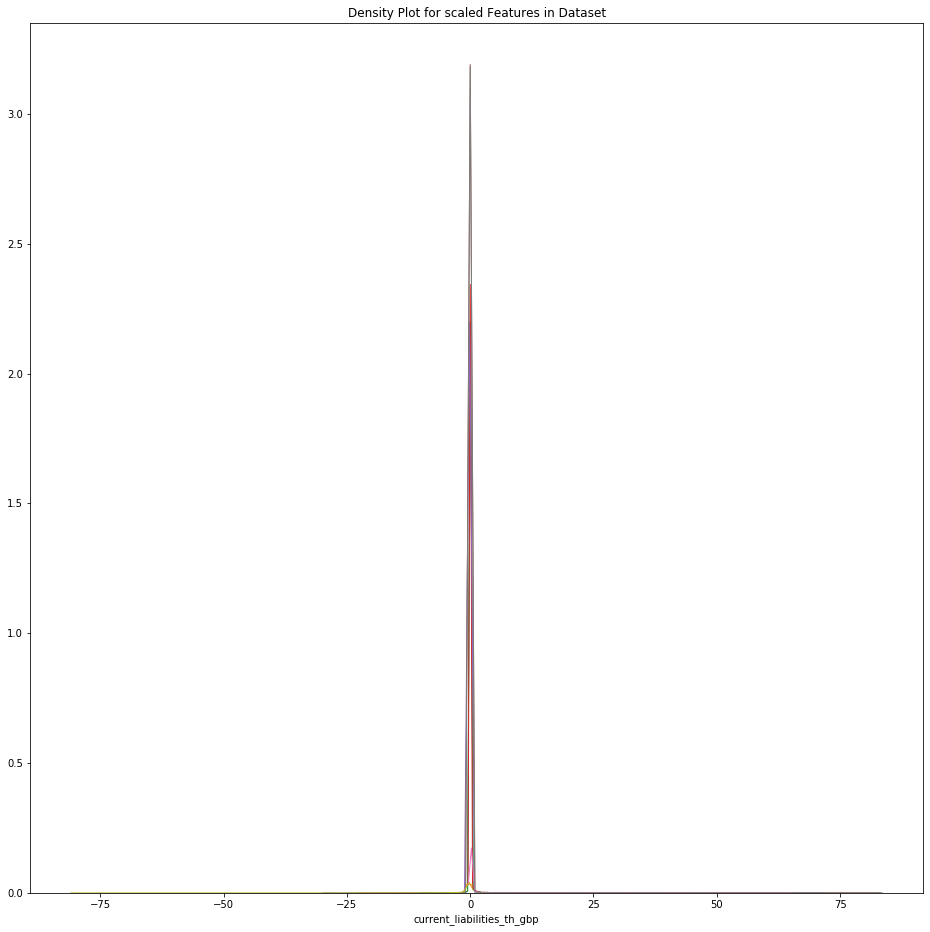

In [13]:
plt.figure(figsize=(16,16))
plt.title('Density Plot for scaled Features in Dataset')
for i in x.columns:
    # Draw the density plot
    sns.distplot(x[i], hist = False, kde = True,
                 kde_kws = {'linewidth': 1})
    

## Fitting a Support Vector Machine
Use Scikit-Learn's support vector classifier to train an SVM model on this data. Let'set the  𝐶  parameter to a very large number.

In [ ]:
from sklearn.svm import SVC # "Support vector classifier"
from timeit import default_timer as timer

model = SVC(kernel='linear', C=1E4)
start = timer()
model.fit(x, y)
end = timer()
print(end - start)

model1 = SVC(kernel='linear', C=1E4)
start = timer()
model1.fit(x_unscaled, y)
end = timer()
print(end - start)




21058.861029569


In [147]:
print(len(model.support_vectors_))
#print(model.support_vectors_)

print(len(model1.support_vectors_))
#print(model1.support_vectors_)

52
60


The SVM fit performed on unscalsed features is 6 times slower and has 8 more support vectors 

From the previous experiences with the Sonar Dataset (https://github.com/borodark/ie7860/blob/master/Feature%20Selection%20and%20Visualization%20Sonar%20Data%20Set.ipynb) we know that several features are more important. Here is 24 best Features by F score: [0  1  3  7  8  9 10 11 12 33 35 36 43 44 45 46 47 48 49 50 51 53 57 59]

Let's fit SVM on 2 and visualize the hyperplane

## Fit SVM on 2 features and visualize the hyperplane

In [148]:
# define the function for plotting the decision boundary
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # Create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)
    
    # Plot decision boundary and margins
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    # Plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=50, linewidth=1, color='#000000', facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

In [149]:
# fit SVM on features [10,50] - 
X = x[[10,50]]
X1 = X.to_numpy()


In [150]:
model3 = SVC(kernel='linear', C=1E4)
start = timer()
model3.fit(X, y)
end = timer()
print(end - start)


0.2013787650002996


There are  99  support vectors 


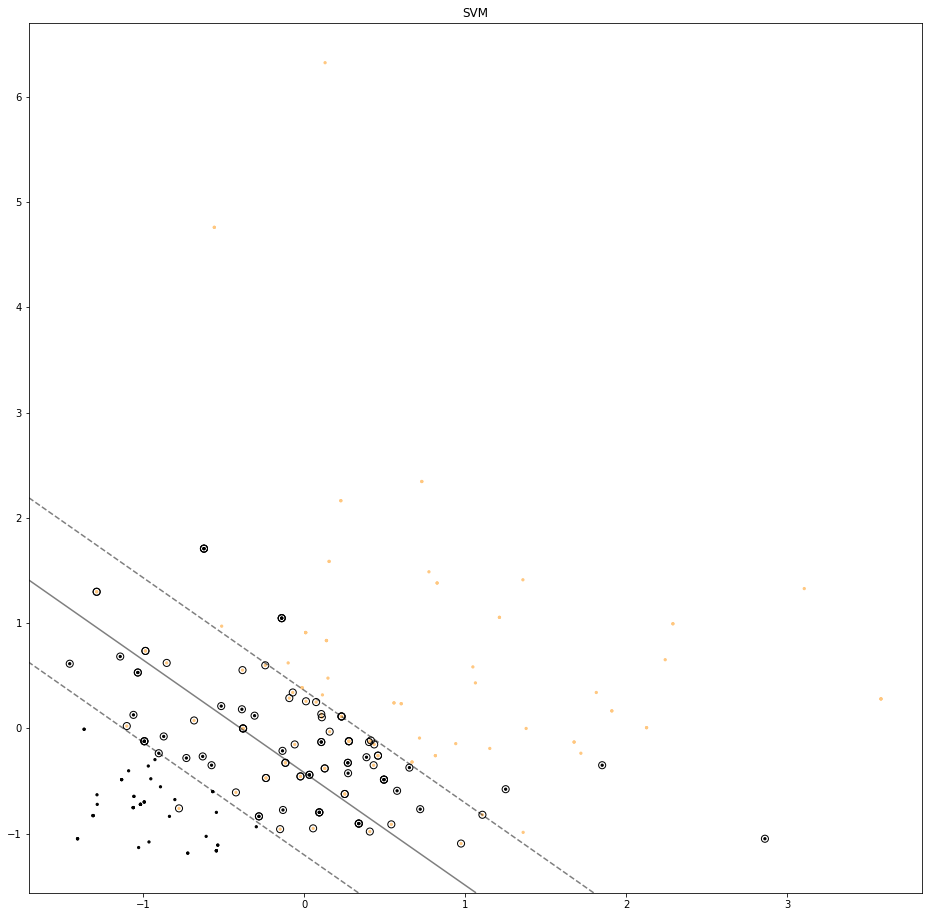

In [151]:
print("There are ", len(model3.support_vectors_), " support vectors ")
plt.figure(figsize=(16,16))
plt.title('SVM')
plt.scatter(X1[:, 0], X1[:, 1], c=y, s=5, cmap='copper')
plot_svc_decision_function(model3);

## Use 'poly' kernel with SVM

In [152]:
poly = SVC(kernel='poly', C=1E4, gamma='scale')
poly.fit(X, y)


SVC(C=10000.0, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='scale', kernel='poly',
    max_iter=-1, probability=False, random_state=None, shrinking=True,
    tol=0.001, verbose=False)

There are  97  support vectors for poly kernel


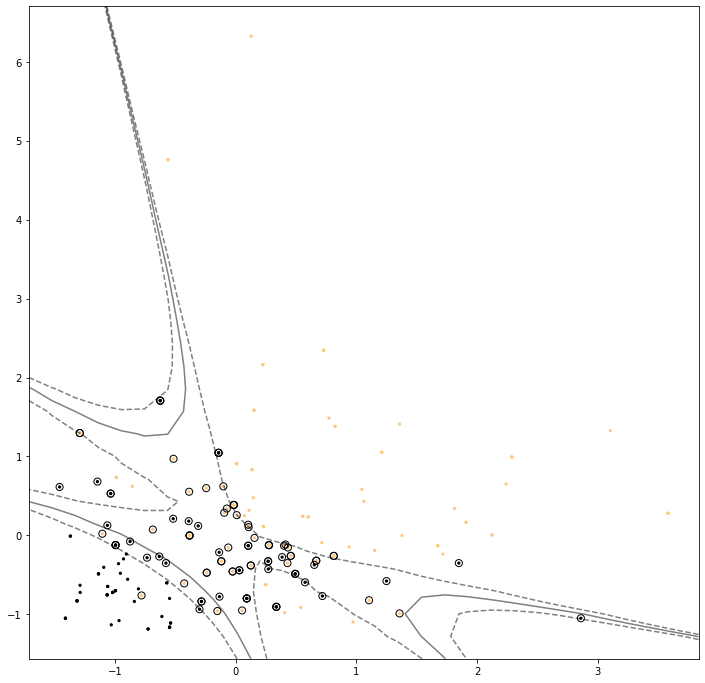

In [156]:
print("There are ", len(poly.support_vectors_), " support vectors for poly kernel")
plt.figure(figsize=(12,12))
plt.scatter(X1[:, 0], X1[:, 1], c=y, s=5, cmap='copper')
plot_svc_decision_function(poly);

## Comparing to other Classifiers

### Scaled features dataset

In [157]:
# Data Processing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

# Metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB


In [158]:
# Create a validation dataset
# Split-out validation dataset
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.20, random_state=1)
X_train[[10,50]].head()

,10,50
23,-1.135619,-0.487021
97,-0.987737,0.735386
94,-0.954159,-0.479428
47,-0.546946,-0.798317
10,-1.312793,-0.828688


In [159]:
X_test[[10,50]].head()

,10,50
24,-1.368517,-0.008688
54,-0.631961,-0.266836
114,0.111740,0.317794
205,0.276054,-0.122577
115,-0.014711,0.386127


In [160]:
# Spot Check Algorithms
models = []
models.append(('LR', LogisticRegression(solver='liblinear', multi_class='ovr')))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC(gamma='auto')))

# Evaluate each model in turn
results = []
names = []
for name, model in models:
	kfold = StratifiedKFold(n_splits=10)
	cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring='accuracy')
	results.append(cv_results)
	names.append(name)
	print('%s: %f (%f)' % (name, cv_results.mean(), cv_results.std()))

LR: 0.850368 (0.069524)
LDA: 0.758824 (0.079809)
KNN: 0.880147 (0.108518)
CART: 0.836397 (0.086663)
NB: 0.747426 (0.057335)
SVM: 0.904779 (0.053212)


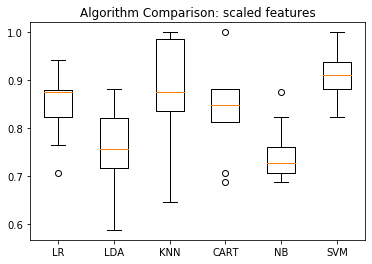

In [161]:
# Compare Algorithms
plt.boxplot(results, labels=names)
plt.title('Algorithm Comparison: scaled features')
plt.show()

SVM has the highest median out of all!

In [162]:
# Make predictions on validation dataset
model = SVC(gamma='auto',C=1E10)
start = timer()
model.fit(X_train, Y_train)
end = timer()
print(end - start)
predictions = model.predict(X_test)

0.003969833999690309


There are  91  support vectors 
0.9761904761904762
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        21
           1       0.95      1.00      0.98        21

    accuracy                           0.98        42
   macro avg       0.98      0.98      0.98        42
weighted avg       0.98      0.98      0.98        42

Confusion Matrix:


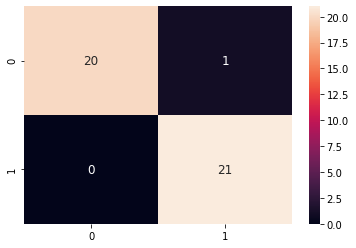

In [163]:
# Evaluate predictions
print("There are ", len(model.support_vectors_), " support vectors ")
print(accuracy_score(Y_test, predictions))
print(classification_report(Y_test, predictions))
cm = confusion_matrix(Y_test,predictions)
print('Confusion Matrix:')
sns.heatmap(cm,annot=True,fmt="d", annot_kws={"size": 12}) # font size

### Unscaled features

In [164]:
# Create a validation dataset
# Split-out validation dataset
X_train, X_test, Y_train, Y_test = train_test_split(x_unscaled, y, test_size=0.20, random_state=1)
# Spot Check Algorithms
models = []
models.append(('LR', LogisticRegression(solver='liblinear', multi_class='ovr')))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC(gamma='auto')))

# Evaluate each model in turn
results = []
names = []
for name, model in models:
	kfold = StratifiedKFold(n_splits=10)
	cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring='accuracy')
	results.append(cv_results)
	names.append(name)
	print('%s: %f (%f)' % (name, cv_results.mean(), cv_results.std()))

LR: 0.785294 (0.114080)
LDA: 0.758824 (0.079809)
KNN: 0.819485 (0.088426)
CART: 0.824265 (0.065639)
NB: 0.747426 (0.057335)
SVM: 0.631985 (0.066043)


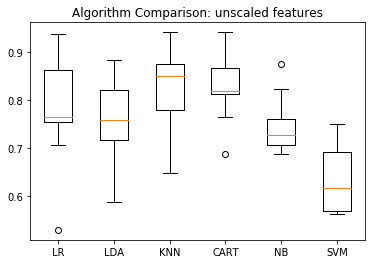

In [165]:
# Compare Algorithms
plt.boxplot(results, labels=names)
plt.title('Algorithm Comparison: unscaled features')
plt.show()

### Conclusion
* The SVM classifier is able to reach %98 accuracy and performs faster then MLP - fit takes only `0.003992759000539081` seconds compare to several minutes for Neural Networks 
* The SVM classifier is sensitive to feature sclaing: slower speed and lower precision